In [2]:
import cobra
from cobra.flux_analysis import production_envelope
# Load iBag597 SBML model file
model = cobra.io.read_sbml_model("ModelFiles/iBag597.xml")

import matplotlib.pyplot as plt

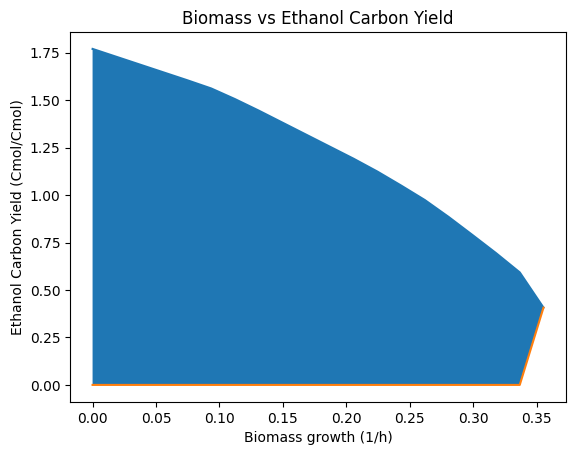

In [3]:
# default model
prod_env = production_envelope(
            model,
            ["EXBiomass"],
            objective='EX0036',
            carbon_sources=["EX0001"]
        )
plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethanol Carbon Yield")
plt.show()

In [ ]:
print(model.reactions.get_by_id('EX0001').lower_bound)

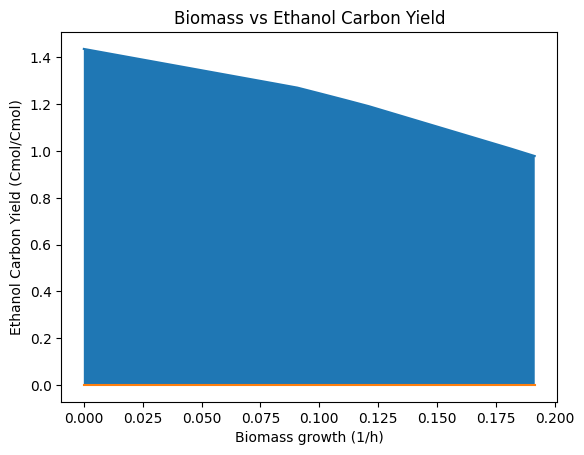

In [5]:
with model:
    # Block O2 
    if "EX0004" in model.reactions:
        model.reactions.EX0004.bounds = (0.0, 0.0)
    # Block non-glucose carbon sources
    # for ex in model.exchanges:
    #     met = next(iter(ex.metabolites))
    #     if met.elements.get("C", 0) and ex.id not in ["EX0001", 'EX0008']:
    #         ex.lower_bound = 0.0

    prod_env = production_envelope(
                model,
                ["EXBiomass"],
                objective='EX0036',
                carbon_sources=["EX0001"]
            )
    plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
    plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
    plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

    plt.xlabel("Biomass growth (1/h)")
    plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
    plt.title("Biomass vs Ethanol Carbon Yield")
    plt.show()